In [1]:
from pyspark.sql import SparkSession

#memulai spark session
spark = SparkSession.builder.appName("BigDataPractice").getOrCreate()

#membuat data
data = [
    ("Ali", 34, "Engineer", "Membaca", "Laki-laki"),
    ("Budi", 23, "Designer", "Bersepeda", "Laki-laki"),
    ("Citra", 29, "Dokter", "Melukis", "Perempuan"),
    ("Dina", 45, "Guru", "Memasak", "Perempuan")
]

#kolom sesuai data
columns = ["Nama", "Usia", "Pekerjaan", "Hobi", "Gender"]

#membuat dataframe
df = spark.createDataFrame(data, columns)

#menampilkan
df.show()

+-----+----+---------+---------+---------+
| Nama|Usia|Pekerjaan|     Hobi|   Gender|
+-----+----+---------+---------+---------+
|  Ali|  34| Engineer|  Membaca|Laki-laki|
| Budi|  23| Designer|Bersepeda|Laki-laki|
|Citra|  29|   Dokter|  Melukis|Perempuan|
| Dina|  45|     Guru|  Memasak|Perempuan|
+-----+----+---------+---------+---------+



In [7]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import avg

#emulai spark session
spark = SparkSession.builder.appName("BigDataPractice").getOrCreate()

#membuat dataframe
data = [("Ali", 34), ("Budi", 23), ("Citra", 29), ("Dina", 45)]
columns = ["Nama", "Usia"]
df = spark.createDataFrame(data, columns)

#dataframe awal
print("Data Awal")
df.show()

#1. filtering data(usia>30)
print("Data dengan Usia > 30")
df_filtered = df.filter(df['Usia'] > 30)
df_filtered.show()

#2.menghitung rata-rata usia
print("Rata-rata Usia")
df.groupBy().agg(avg("Usia").alias("Rata_rata_Usia")).show()

#3.mengurutkan data berdasarkan usia(descending)
print("Data Diurutkan Usia (Descending)")
df_sorted = df.orderBy("Usia", ascending=False)
df_sorted.show()

Data Awal
+-----+----+
| Nama|Usia|
+-----+----+
|  Ali|  34|
| Budi|  23|
|Citra|  29|
| Dina|  45|
+-----+----+

Data dengan Usia > 30
+----+----+
|Nama|Usia|
+----+----+
| Ali|  34|
|Dina|  45|
+----+----+

Rata-rata Usia
+--------------+
|Rata_rata_Usia|
+--------------+
|         32.75|
+--------------+

Data Diurutkan Usia (Descending)
+-----+----+
| Nama|Usia|
+-----+----+
| Dina|  45|
|  Ali|  34|
|Citra|  29|
| Budi|  23|
+-----+----+



In [8]:
import pandas as pd

#dataframe pandas awal
data_pandas = {
    "Nama": ["Ali", "Budi", "Citra", "Dina"],
    "Usia": [34, 23, 29, 45]
}
df_pandas = pd.DataFrame(data_pandas)

#nambah kolom
df_pandas["Pekerjaan"] = ["Programmer", "Desainer", "Guru", "Dokter"]
df_pandas["Hobi"] = ["Membaca", "Gaming", "Memasak", "Traveling"]
df_pandas["Gender"] = ["L", "L", "P", "P"]

print("DataFrame Awal dengan Kolom Tambahan")
print(df_pandas)

#filtering berdasarkan usia > 30
df_filtered = df_pandas[df_pandas["Usia"] > 30]

print("\nData Usia > 30")
print(df_filtered)

DataFrame Awal dengan Kolom Tambahan
    Nama  Usia   Pekerjaan       Hobi Gender
0    Ali    34  Programmer    Membaca      L
1   Budi    23    Desainer     Gaming      L
2  Citra    29        Guru    Memasak      P
3   Dina    45      Dokter  Traveling      P

Data Usia > 30
   Nama  Usia   Pekerjaan       Hobi Gender
0   Ali    34  Programmer    Membaca      L
3  Dina    45      Dokter  Traveling      P


DataFrame Hasil Join
    Nama  Usia Pekerjaan
0    Ali    34    Dokter
1   Budi    23      Guru
2  Citra    29  Insinyur
3   Dina    45   Perawat

Statistik Deskriptif Usia
            Usia
count   4.000000
mean   32.750000
std     9.322911
min    23.000000
25%    27.500000
50%    31.500000
75%    36.750000
max    45.000000


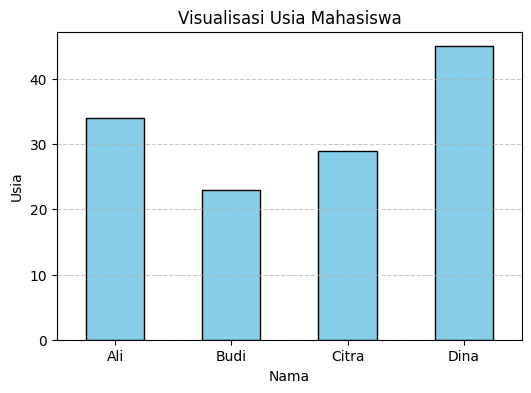

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

#dataframe
data_pandas = {
    "Nama": ["Ali", "Budi", "Citra", "Dina"],
    "Usia": [34, 23, 29, 45]
}
df_pandas = pd.DataFrame(data_pandas)

#dataframe2
data_pandas_2 = {
    "Nama": ["Ali", "Budi", "Citra", "Dina"],
    "Pekerjaan": ["Dokter", "Guru", "Insinyur", "Perawat"]
}
df_pandas_2 = pd.DataFrame(data_pandas_2)

#1. join antara dua DataFrame berdasarkan kolom nama
df_joined = pd.merge(df_pandas, df_pandas_2, on="Nama")

print("DataFrame Hasil Join")
print(df_joined)

#2. statistik deskriptif
print("\nStatistik Deskriptif Usia")
print(df_pandas.describe())

#3. bar chart
plt.figure(figsize=(6,4))
df_pandas.set_index("Nama")["Usia"].plot(kind="bar", color="skyblue", edgecolor="black")

plt.title("Visualisasi Usia Mahasiswa")
plt.xlabel("Nama")
plt.ylabel("Usia")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [10]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import avg
import pandas as pd

#1. spark session
spark = SparkSession.builder.appName("BigDataPractice").getOrCreate()

#2. data awal di PySpark
data_spark = [
    ("Ali", 34),
    ("Budi", 23),
    ("Citra", 29),
    ("Dina", 45)
]
columns_spark = ["Nama", "Usia"]
df_spark = spark.createDataFrame(data_spark, columns_spark)

print("Data dari PySpark")
df_spark.show()

#3. data tambahan di Pandas
data_pandas = {
    "Nama": ["Eko", "Farah", "Gita"],
    "Usia": [31, 28, 40]
}
df_pandas = pd.DataFrame(data_pandas)

print("\nData dari Pandas")
print(df_pandas)

#4. konversi Pandas -> PySpark
df_spark_from_pandas = spark.createDataFrame(df_pandas)

#5. gabungkan data
df_combined = df_spark.union(df_spark_from_pandas)

print("\nData Gabungan (PySpark + Pandas)")
df_combined.show()

#6. analisis sederhana
df_combined.groupBy().agg(avg("Usia").alias("Rata_rata_Usia")).show()

Data dari PySpark
+-----+----+
| Nama|Usia|
+-----+----+
|  Ali|  34|
| Budi|  23|
|Citra|  29|
| Dina|  45|
+-----+----+


Data dari Pandas
    Nama  Usia
0    Eko    31
1  Farah    28
2   Gita    40

Data Gabungan (PySpark + Pandas)
+-----+----+
| Nama|Usia|
+-----+----+
|  Ali|  34|
| Budi|  23|
|Citra|  29|
| Dina|  45|
|  Eko|  31|
|Farah|  28|
| Gita|  40|
+-----+----+

+------------------+
|    Rata_rata_Usia|
+------------------+
|32.857142857142854|
+------------------+



In [11]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import max
import pandas as pd

#1. spark session
spark = SparkSession.builder.appName("BigDataPractice").getOrCreate()

#2. data awal di PySpark
data_spark = [
    ("Ali", 34),
    ("Budi", 23),
    ("Citra", 29),
    ("Dina", 45)
]
columns_spark = ["Nama", "Usia"]
df_spark = spark.createDataFrame(data_spark, columns_spark)

print("Data dari PySpark")
df_spark.show()

#3. data tambahan di Pandas
data_pandas = {
    "Nama": ["Eko", "Farah", "Gita"],
    "Usia": [31, 28, 40]
}
df_pandas = pd.DataFrame(data_pandas)

print("\nData dari Pandas")
print(df_pandas)

#4. konversi Pandas -> PySpark
df_spark_from_pandas = spark.createDataFrame(df_pandas)

#5. gabungkan data
df_combined = df_spark.union(df_spark_from_pandas)

print("\nData Gabungan (PySpark + Pandas)")
df_combined.show()

#6. operasi statistik
df_combined.agg(max("Usia").alias("Maksimum_Usia")).show()

Data dari PySpark
+-----+----+
| Nama|Usia|
+-----+----+
|  Ali|  34|
| Budi|  23|
|Citra|  29|
| Dina|  45|
+-----+----+


Data dari Pandas
    Nama  Usia
0    Eko    31
1  Farah    28
2   Gita    40

Data Gabungan (PySpark + Pandas)
+-----+----+
| Nama|Usia|
+-----+----+
|  Ali|  34|
| Budi|  23|
|Citra|  29|
| Dina|  45|
|  Eko|  31|
|Farah|  28|
| Gita|  40|
+-----+----+

+-------------+
|Maksimum_Usia|
+-------------+
|           45|
+-------------+

